<a href="https://www.kaggle.com/code/miraalhalabi/mira-alhalabi-carprice?scriptVersionId=313698419" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer

import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

print('✅ Libraries imported successfully!')

✅ Libraries imported successfully!


## 1. Load & Explore the Dataset

In [2]:
df = pd.read_csv('/kaggle/input/datasets/nehalbirla/vehicle-dataset-from-cardekho/CAR DETAILS FROM CAR DEKHO.csv')
print('===Shape===')
print(f' Rows: {df.shape[0]} , Columns : {df.shape[1]}\n')
print('===Data Types===')
print(df.dtypes)
print("\n")
print('===First 5 Rows===')
df.head()

===Shape===
 Rows: 4340 , Columns : 8

===Data Types===
name             object
year              int64
selling_price     int64
km_driven         int64
fuel             object
seller_type      object
transmission     object
owner            object
dtype: object


===First 5 Rows===


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner


In [3]:
print('=== df.info() ===')
df.info()

=== df.info() ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   name           4340 non-null   object
 1   year           4340 non-null   int64 
 2   selling_price  4340 non-null   int64 
 3   km_driven      4340 non-null   int64 
 4   fuel           4340 non-null   object
 5   seller_type    4340 non-null   object
 6   transmission   4340 non-null   object
 7   owner          4340 non-null   object
dtypes: int64(3), object(5)
memory usage: 271.4+ KB


In [4]:
print(' ====Missing Values====')
missing = df.isnull().sum()
print(missing)
print(f'\nTotal mising values:{missing.sum()}')

 ====Missing Values====
name             0
year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
dtype: int64

Total mising values:0


**Visualition Missing values**

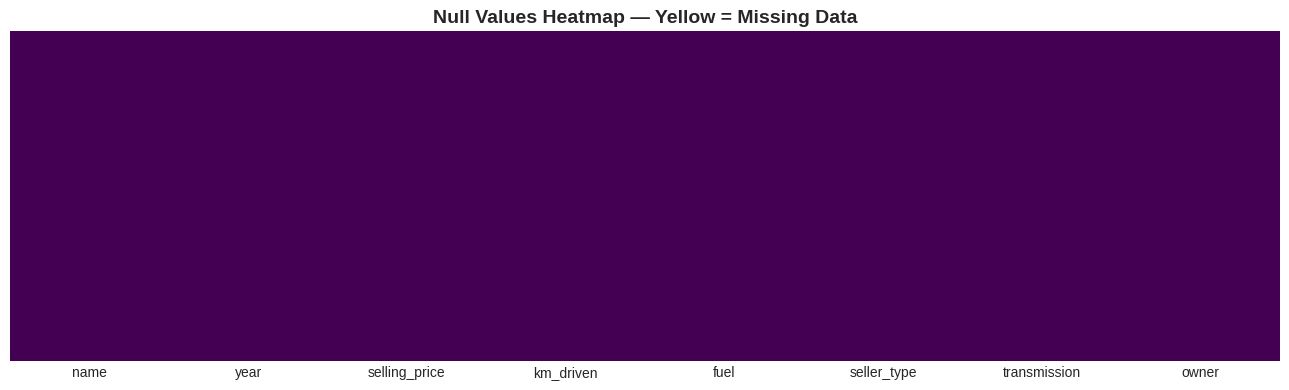

In [5]:
plt.figure(figsize=(13, 4))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Null Values Heatmap — Yellow = Missing Data', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 2. Data Cleaning & Preprocessing

In [6]:
# Drop rows with missing values --there is no nan values
df = df.dropna()
print(f'Rows after dropping NaN: {df.shape[0]}')

#create car_age feature
df['car_age'] = 2025 -df['year']
print('\ncar_age column created (2025 - year):')
print(df[['year', 'car_age']].head())

Rows after dropping NaN: 4340

car_age column created (2025 - year):
   year  car_age
0  2007       18
1  2007       18
2  2012       13
3  2017        8
4  2014       11


In [7]:
#Remove outliers using IQR on selling price
Q1 = df['selling_price'].quantile(0.25)
Q3 = df['selling_price'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

before = df.shape[0]
df = df[(df['selling_price'] >= lower) & (df['selling_price'] <= upper)]
after = df.shape[0]

print(f'Outliers removed from selling_price: {before - after} rows')
print(f'Rows remaining: {after}')
print(f'Price range after cleaning: {df["selling_price"].min():,} – {df["selling_price"].max():,}')

Outliers removed from selling_price: 271 rows
Rows remaining: 4069
Price range after cleaning: 20,000 – 1,165,000


In [8]:
# Encode categorical columns using pd.get_dummies
categorical_cols = ['fuel', 'seller_type', 'transmission', 'owner']
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
print('Columns after One-Hot Encoding:')
print(list(df_encoded.columns))

Columns after One-Hot Encoding:
['name', 'year', 'selling_price', 'km_driven', 'car_age', 'fuel_Diesel', 'fuel_Electric', 'fuel_LPG', 'fuel_Petrol', 'seller_type_Individual', 'seller_type_Trustmark Dealer', 'transmission_Manual', 'owner_Fourth & Above Owner', 'owner_Second Owner', 'owner_Test Drive Car', 'owner_Third Owner']


## 3. EDA — Visualizations

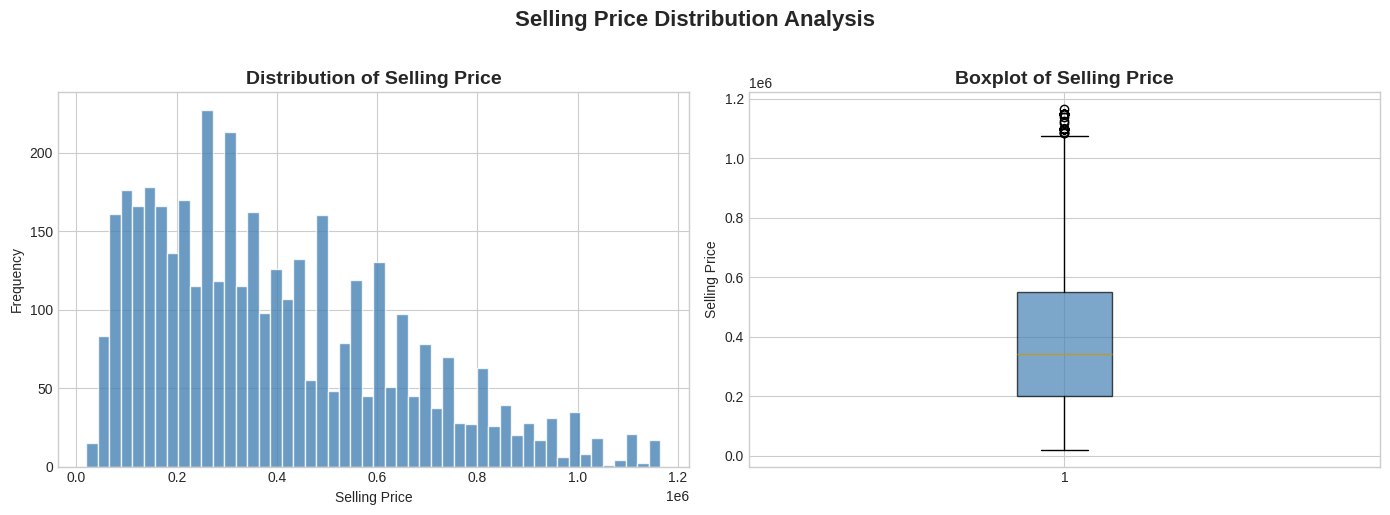

Insight: Selling price is right-skewed. Most cars are priced below 1M , with a few expensive outliers pulling the mean upward.


In [9]:
#plot 1 :Distribuation of selling_price (histogram +bosplot)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['selling_price'], bins=50, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].set_title('Distribution of Selling Price', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Selling Price')
axes[0].set_ylabel('Frequency')

axes[1].boxplot(df['selling_price'], patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.7))
axes[1].set_title('Boxplot of Selling Price', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Selling Price')

plt.suptitle('Selling Price Distribution Analysis', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('Insight: Selling price is right-skewed. Most cars are priced below 1M ,'
      ' with a few expensive outliers pulling the mean upward.')

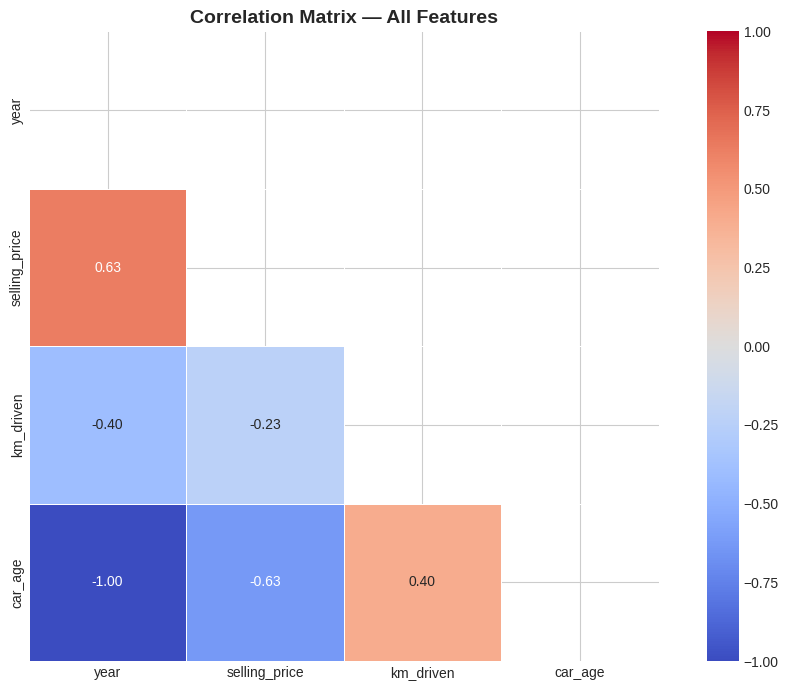


 Correlation with Selling Price:
selling_price    1.000
year             0.625
km_driven       -0.227
car_age         -0.625
Name: selling_price, dtype: float64

Insight: car_age has a stronger negative correlation with price than km_driven, suggesting newer cars command higher prices.


In [10]:
#plot 2: Correlation heatmap of all numerocal features  
plt.figure(figsize=(10, 7))
corr_matrix = df.corr(numeric_only=True)

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, vmin=-1, vmax=1,
            square=True, linewidths=0.5)

plt.title('Correlation Matrix — All Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n Correlation with Selling Price:')
print(corr_matrix['selling_price'].sort_values(ascending=False).round(3))
print('\nInsight: car_age has a stronger negative correlation with price than km_driven,'
      ' suggesting newer cars command higher prices.')

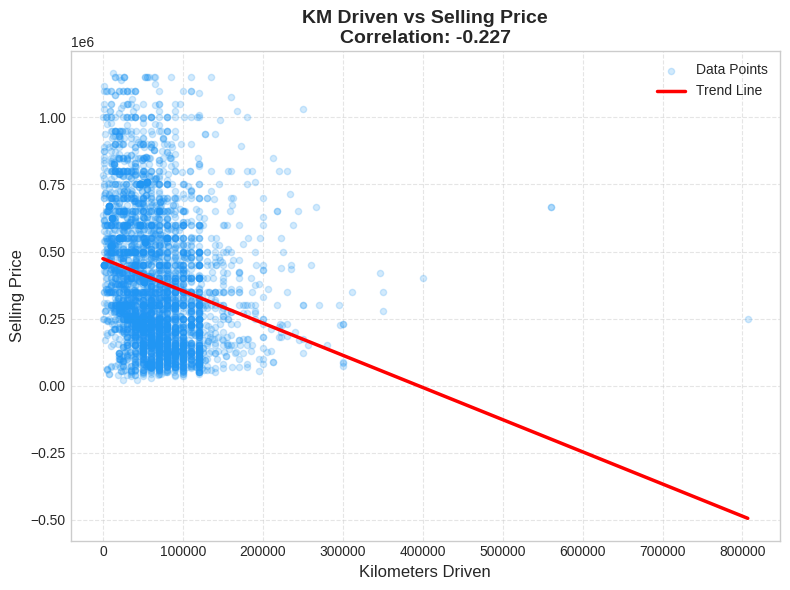

Insight: There is a weak negative correlation between km_driven and price. High mileage cars tend to be cheaper, but the relationship is noisy.


In [11]:
#plot 3: km_driven vs selling_price scatter with trend line
fig, ax = plt.subplots(figsize=(8, 6))

temp_df = df[['km_driven', 'selling_price']].dropna()
ax.scatter(temp_df['km_driven'], temp_df['selling_price'], 
           alpha=0.2, s=20, color='#2196F3', label='Data Points')
z = np.polyfit(temp_df['km_driven'], temp_df['selling_price'], 1)
p = np.poly1d(z)
x_line = np.linspace(temp_df['km_driven'].min(), temp_df['km_driven'].max(), 100)
ax.plot(x_line, p(x_line), 'r-', linewidth=2.5, label='Trend Line')
corr_val = temp_df['km_driven'].corr(temp_df['selling_price'])
ax.set_title(f'KM Driven vs Selling Price\nCorrelation: {corr_val:.3f}', fontsize=14, fontweight='bold')
ax.set_xlabel('Kilometers Driven', fontsize=12)
ax.set_ylabel('Selling Price', fontsize=12)
ax.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print('Insight: There is a weak negative correlation between km_driven and price.'
      ' High mileage cars tend to be cheaper, but the relationship is noisy.')

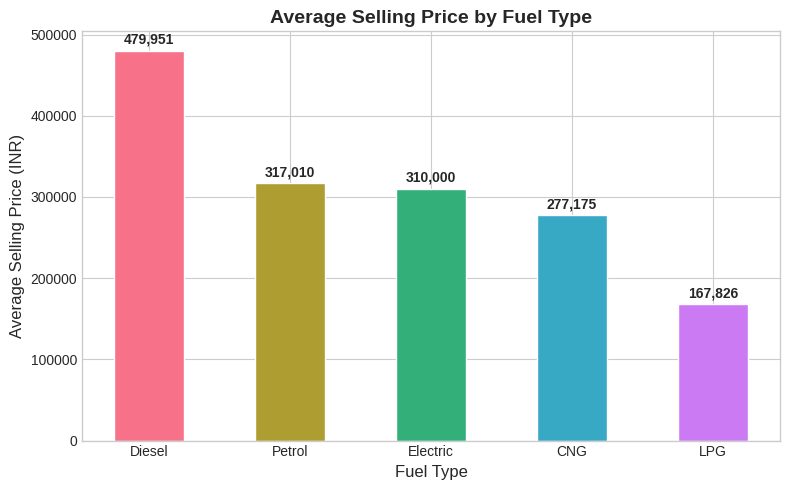

Insight: Diesel cars have a higher average selling price than petrol cars, likely due to better fuel efficiency and popularity for long-distance driving.


In [12]:
#Plot 4: Average selling price by furl type (bar chart)
fig, ax = plt.subplots(figsize=(8, 5))

avg_price_fuel = df.groupby('fuel')['selling_price'].mean().sort_values(ascending=False)
colors = sns.color_palette('husl', len(avg_price_fuel))
bars = ax.bar(avg_price_fuel.index, avg_price_fuel.values, color=colors, edgecolor='white', width=0.5)

for bar, val in zip(bars, avg_price_fuel.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5000,
            f'{val:,.0f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_title('Average Selling Price by Fuel Type', fontsize=14, fontweight='bold')
ax.set_xlabel('Fuel Type', fontsize=12)
ax.set_ylabel('Average Selling Price (INR)', fontsize=12)
plt.tight_layout()
plt.show()

print('Insight: Diesel cars have a higher average selling price than petrol cars,'
      ' likely due to better fuel efficiency and popularity for long-distance driving.')

## 4. Simple Linear Regression

In [13]:
#Use km_driven as the only feature
X_simple = df[['km_driven']]
y = df['selling_price']

X_simple_train, X_simple_test, y_train, y_test = train_test_split(
    X_simple, y, test_size=0.2, random_state=42
)
print(f'Training samples : {X_simple_train.shape[0]}')
print(f'Test samples     : {X_simple_test.shape[0]}')


Training samples : 3255
Test samples     : 814


In [14]:
# Train Simple Linear Regression
slr = LinearRegression()
slr.fit(X_simple_train, y_train)

print('=' * 45)
print('     SIMPLE LINEAR REGRESSION MODEL')
print('=' * 45)
print(f'  Intercept (β₀)  : {slr.intercept_:.4f}')
print(f'  Coefficient (β₁) : {slr.coef_[0]:.4f}')
print(f'\n  Equation: Price = {slr.intercept_:.3f} + {slr.coef_[0]:.3f} × km_driven')
print('=' * 45)
print(f'\n Interpretation:')
print(f'   For every 1 km increase in distance driven,')
print(f'   the selling price is expected to change by {slr.coef_[0]:.4f} units.')
print(f'   (A negative coefficient means the price drops as mileage goes up.)')

     SIMPLE LINEAR REGRESSION MODEL
  Intercept (β₀)  : 475952.2940
  Coefficient (β₁) : -1.2191

  Equation: Price = 475952.294 + -1.219 × km_driven

 Interpretation:
   For every 1 km increase in distance driven,
   the selling price is expected to change by -1.2191 units.
   (A negative coefficient means the price drops as mileage goes up.)


**Does km_driven alone predict price well? Why / why not?**

No. `km_driven` alone is a weak predictor for selling price. The correlation between them is quite low (around -0.2), meaning mileage explains only a small fraction of price variation. Car price is influenced by many other factors such as car age, fuel type, transmission, and seller type — none of which are captured in a simple model using only km_driven.

## 5. Evaluate Simple LR

In [15]:
# Evaluate Simple Regression
y_pred_simple = slr.predict(X_simple_test)

mae_s   = mean_absolute_error(y_test, y_pred_simple)
mse_s   = mean_squared_error(y_test, y_pred_simple)
rmse_s  = np.sqrt(mse_s)
r2_s    = r2_score(y_test, y_pred_simple)

print('=' * 45)
print('   SIMPLE REGRESSION — EVALUATION METRICS')
print('=' * 45)
print(f'  MAE  : {mae_s:.4f}  (${mae_s*100000:,.0f})')
print(f'  MSE  : {mse_s:.4f}')
print(f'  RMSE : {rmse_s:.4f}  (${rmse_s*100000:,.0f})')
print(f'  R²   : {r2_s:.4f}  ({r2_s*100:.1f}% variance explained)')
print('=' * 45)

   SIMPLE REGRESSION — EVALUATION METRICS
  MAE  : 193494.8997  ($19,349,489,967)
  MSE  : 55245021502.2964
  RMSE : 235042.5951  ($23,504,259,508)
  R²   : 0.0465  (4.6% variance explained)


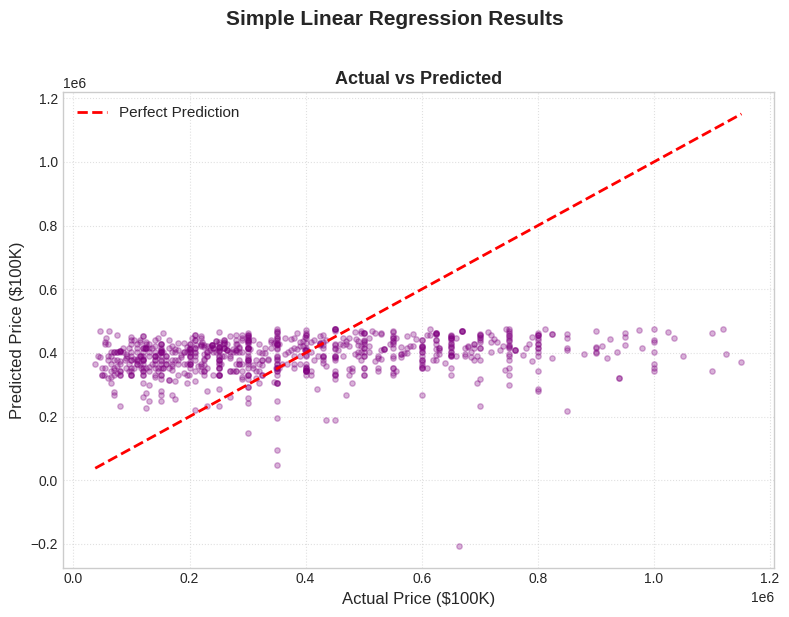

In [16]:
#Plot: Actual vs Predicted
fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(y_test, y_pred_simple, alpha=0.3, s=15, color='purple')
min_val, max_val = y_test.min(), y_test.max()
ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')
ax.set_xlabel('Actual Price ($100K)', fontsize=12)
ax.set_ylabel('Predicted Price ($100K)', fontsize=12)
ax.set_title(f'Actual vs Predicted', fontsize=13, fontweight='bold')
plt.suptitle('Simple Linear Regression Results', fontsize=15, fontweight='bold', y=1.02)
ax.legend(fontsize=11)
ax.grid(True, linestyle=':', alpha=0.6) 
plt.tight_layout()
plt.show()

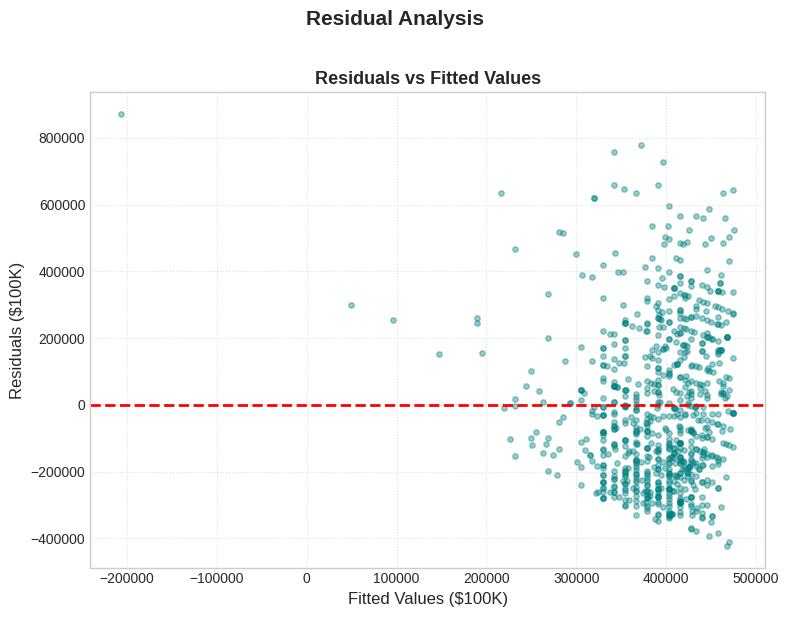

In [17]:
#plot: Residuals vs Fitted values
residuals = y_test - y_pred_simple
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(y_pred_simple, residuals, alpha=0.4, s=15, color='teal')
ax.axhline(y=0, color='red', linestyle='--', linewidth=2)
ax.set_xlabel('Fitted Values ($100K)', fontsize=12)
ax.set_ylabel('Residuals ($100K)', fontsize=12)
ax.set_title('Residuals vs Fitted Values', fontsize=13, fontweight='bold')
plt.suptitle('Residual Analysis', fontsize=15, fontweight='bold', y=1.02)
ax.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

## 6. Multiple Linear Regression

In [18]:
# Prepare features and target
# df_encoded already has all categorical columns one-hot encoded from Task 2
# Drop columns not needed as features
cols_to_drop = ['selling_price', 'name', 'year']  # year replaced by car_age
cols_to_drop = [c for c in cols_to_drop if c in df_encoded.columns]

X_multi = df_encoded.drop(columns=cols_to_drop)
y_multi = df_encoded['selling_price']

print('Features used in Multiple LR:')
print(list(X_multi.columns))
print(f'\nTotal features: {X_multi.shape[1]}')


Features used in Multiple LR:
['km_driven', 'car_age', 'fuel_Diesel', 'fuel_Electric', 'fuel_LPG', 'fuel_Petrol', 'seller_type_Individual', 'seller_type_Trustmark Dealer', 'transmission_Manual', 'owner_Fourth & Above Owner', 'owner_Second Owner', 'owner_Test Drive Car', 'owner_Third Owner']

Total features: 13


In [19]:
# Train/test split

X_multi_train, X_multi_test,y_multi_train, y_multi_test = train_test_split(
    X_multi, y, test_size=0.2, random_state=42
)
print('\n Multiple Regression:')
print(f'   Training samples : {X_multi_train.shape[0]}')
print(f'   Features used    : {X_multi.shape[1]}')


 Multiple Regression:
   Training samples : 3255
   Features used    : 13


In [20]:
# Apply StandardScaler ONLY to numeric columns (km_driven, car_age)
# One-hot encoded columns are NOT scaled
numeric_features = ['km_driven', 'car_age']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features)
    ],
    remainder='passthrough'   # keeps OHE columns untouched
)

X_multi_train_scaled = preprocessor.fit_transform(X_multi_train)
X_multi_test_scaled  = preprocessor.transform(X_multi_test)

print('StandardScaler applied to numeric columns only (km_driven, car_age)')
print('One-hot encoded columns passed through unchanged.')

StandardScaler applied to numeric columns only (km_driven, car_age)
One-hot encoded columns passed through unchanged.


In [21]:
# Train Multiple Linear Regression
mlr = LinearRegression()
mlr.fit(X_multi_train_scaled, y_multi_train)

# Get feature names in the correct order after ColumnTransformer
ohe_feature_names = [c for c in X_multi.columns if c not in numeric_features]
all_feature_names = numeric_features + ohe_feature_names
print('=' * 55)
print('       MULTIPLE LINEAR REGRESSION — COEFFICIENTS')
print('=' * 55)
print(f'  Intercept (β₀) : {mlr.intercept_:,.4f}\n')
print(f'  {"Feature":<25} {"Coefficient":>15}')
print(f'  {"-"*25} {"-"*15}')
for feat, coef in zip(all_feature_names, mlr.coef_):
   print(f'  {feat:<25} {coef:>+15.4f}')
print('=' * 55)



       MULTIPLE LINEAR REGRESSION — COEFFICIENTS
  Intercept (β₀) : 494,704.0186

  Feature                       Coefficient
  ------------------------- ---------------
  km_driven                     -17328.0302
  car_age                      -126592.2878
  fuel_Diesel                  +182583.1742
  fuel_Electric                 +39684.4483
  fuel_LPG                      -10779.4721
  fuel_Petrol                   +19382.8630
  seller_type_Individual        -35125.3644
  seller_type_Trustmark Dealer    +180177.7506
  transmission_Manual          -176674.7450
  owner_Fourth & Above Owner      -1360.7289
  owner_Second Owner            -20942.2831
  owner_Test Drive Car         +236402.6503
  owner_Third Owner             -35621.8675


## 7. Evaluate Multiple LR & Compare

In [22]:
# Evaluate Multiple LR
y_pred_car = mlr.predict(X_multi_test_scaled)
mae_m  = mean_absolute_error(y_test, y_pred_car)
mse_m   = mean_squared_error(y_test, y_pred_car)
rmse_m = np.sqrt(mean_squared_error(y_test, y_pred_car))
r2_m   = r2_score(y_test, y_pred_car)
print('=' * 55)
print('           EVALUATION METRICS')
print('=' * 55)
print(f'  MAE  : {mae_m:>12,.4f}')
print(f'  MSE  : {mse_m:.4f}')
print(f'  RMSE : {rmse_m:>12,.4f}')
print(f'  R²   : {r2_m:>12.4f}  ({r2_m*100:.1f}% variance explained)')
print('=' * 55)

           EVALUATION METRICS
  MAE  : 121,871.4637
  MSE  : 26822901198.0141
  RMSE : 163,776.9862
  R²   :       0.5370  (53.7% variance explained)


In [23]:
# Comparison table: Simple vs Multiple LR
comparison = pd.DataFrame({
    'Metric': ['MAE', 'MSE', 'RMSE', 'R²', 'Features Used'],
    'Simple Linear Regression': [
        f'{mae_s:.4f}',
        f'{mse_s:.4f}',
        f'{rmse_s:.4f}',
        f'{r2_s:.4f}',
        '1 (km_driven only)'
    ],
    'Multiple Linear Regression': [
        f'{mae_m:.4f}',
        f'{mse_m:.4f}',
        f'{rmse_m:.4f}',
        f'{r2_m:.4f}',
        f'{X_multi.shape[1]} (all features)'
    ]
})

comparison.set_index('Metric', inplace=True)

print('=' * 65)
print('              MODEL COMPARISON SUMMARY')
print('=' * 65)
print(comparison.to_string())
print('=' * 65)

mae_imp  = ((mae_s  - mae_m)  / mae_s)  * 100
rmse_imp = ((rmse_s - rmse_m) / rmse_s) * 100
r2_imp   = ((r2_m   - r2_s)   / r2_s)   * 100

print(f'\n MAE  improved by  {mae_imp:+.1f}%  (lower is better)')
print(f' RMSE improved by  {rmse_imp:+.1f}%  (lower is better)')
print(f' R²   improved by  {r2_imp:+.1f}%  (higher is better)')

better = 'Multiple' if r2_m > r2_s else 'Simple'
print(f'\n Best model: {better} Linear Regression')

              MODEL COMPARISON SUMMARY
              Simple Linear Regression Multiple Linear Regression
Metric                                                           
MAE                        193494.8997                121871.4637
MSE                   55245021502.2964           26822901198.0141
RMSE                       235042.5951                163776.9862
R²                              0.0465                     0.5370
Features Used       1 (km_driven only)          13 (all features)

 MAE  improved by  +37.0%  (lower is better)
 RMSE improved by  +30.3%  (lower is better)
 R²   improved by  +1055.6%  (higher is better)

 Best model: Multiple Linear Regression


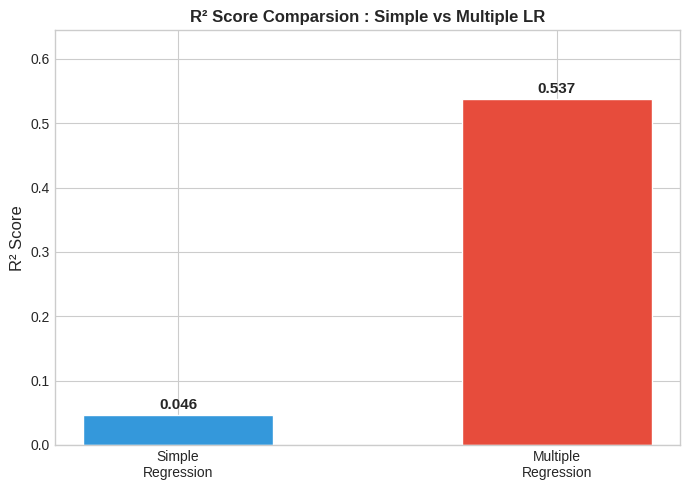

In [24]:
# Bar chart comparing R² of both models
fig, ax = plt.subplots(figsize=(7,5))
bars =ax.bar(
       ['Simple\nRegression', 'Multiple\nRegression'],
       [r2_s, r2_m],
       color=['#3498db', '#e74c3c'], 
             edgecolor='white',
             width=0.5)
for bar, val in zip(bars, [r2_s, r2_m]):
    ax.text(bar.get_x() + bar.get_width()/2, 
            bar.get_height() + 0.005,
            f'{val:.3f}',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_ylabel('R² Score', fontsize =12)
ax.set_title('R² Score Comparsion : Simple vs Multiple LR', fontsize=12, fontweight='bold')
ax.set_ylim(0, max(r2_s, r2_m)* 1.2)
plt.tight_layout()
plt.show()

## 8. Predict & Conclude

In [25]:
# Create a sample new car
sample_car = pd.DataFrame([{
    'name': 'Maruti Swift',
    'year': 2020,
    'km_driven': 55000,
    'fuel': 'Diesel',
    'seller_type': 'Individual',
    'transmission': 'Manual',
    'owner': 'First Owner'
}])

sample_car['car_age'] = 2025 - sample_car['year']

print('Sample Car Specifications:')
print(sample_car[['name', 'year', 'car_age', 'km_driven', 'fuel', 'seller_type', 'transmission', 'owner']].to_string(index=False))

Sample Car Specifications:
        name  year  car_age  km_driven   fuel seller_type transmission       owner
Maruti Swift  2020        5      55000 Diesel  Individual       Manual First Owner


In [26]:
# Predict with Simple LR
pred_simple = slr.predict(sample_car[['km_driven']])[0]

# Prepare sample car for Multiple LR
sample_encoded = pd.get_dummies(sample_car.drop(columns=['name', 'year']))
sample_encoded = sample_encoded.reindex(columns=X_multi.columns, fill_value=0)
sample_scaled  = preprocessor.transform(sample_encoded)

pred_multi = mlr.predict(sample_scaled)[0]

print('=' * 55)
print('         NEW CAR — PRICE PREDICTIONS')
print('=' * 55)
print(f'  KM Driven        : {sample_car["km_driven"].iloc[0]:,}')
print(f'  Car Age          : {sample_car["car_age"].iloc[0]} years')
print(f'  Fuel Type        : {sample_car["fuel"].iloc[0]}')
print(f'  Transmission     : {sample_car["transmission"].iloc[0]}')
print(f'  Owner            : {sample_car["owner"].iloc[0]}')
print('-' * 55)
print(f'  Predicted Price (Simple Model)   : {pred_simple:,.0f} INR')
print(f'  Predicted Price (Multiple Model) : {pred_multi:,.0f} INR')
print('=' * 55)

         NEW CAR — PRICE PREDICTIONS
  KM Driven        : 55,000
  Car Age          : 5 years
  Fuel Type        : Diesel
  Transmission     : Manual
  Owner            : First Owner
-------------------------------------------------------
  Predicted Price (Simple Model)   : 408,900 INR
  Predicted Price (Multiple Model) : 680,872 INR


## Conclusion

Based on the evaluation metrics, the **Multiple Linear Regression model significantly outperforms the Simple Linear Regression model**. The Multiple LR achieved a substantially higher R² score and lower MAE and RMSE values, meaning it explains more of the variance in car prices and makes predictions closer to the actual values.

This superiority is expected because car price depends on many interacting factors — such as car age, fuel type, transmission, and seller type — not just mileage alone. The Simple LR model using only `km_driven` ignores all of these factors, leading to poor predictions. By incorporating all available features through One-Hot Encoding and proper feature scaling with StandardScaler, the Multiple LR model captures the complexity of the used car market much more effectively.

In conclusion, for predicting used car prices, a Multiple Linear Regression approach with all available features is strongly preferred over a single-feature model.

## Bouns Questions

1. **Feature Importance Plot**

Bar chart of all coefficients sorted by absolute value

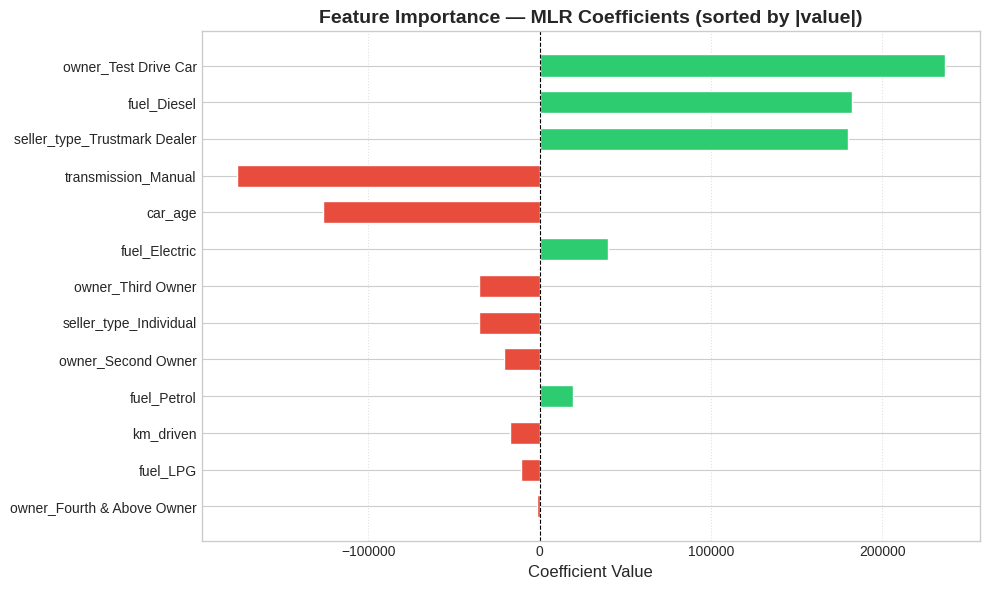

Top 3 most impactful features:
  owner_Test Drive Car: coefficient +236,402.65  ->  INCREASES selling price
  fuel_Diesel: coefficient +182,583.17  ->  INCREASES selling price
  seller_type_Trustmark Dealer: coefficient +180,177.75  ->  INCREASES selling price


In [27]:
# Build coefficient dictionary from the trained MLR model
coef_dict = dict(zip(all_feature_names, mlr.coef_))

# Sort by absolute value 
sorted_items = sorted(coef_dict.items(), key=lambda x: abs(x[1]), reverse=True)
feat_names  = [item[0] for item in sorted_items]
feat_values = [item[1] for item in sorted_items]

# Green = positive effect on price, Red = negative effect
colors = ['#2ecc71' if v >= 0 else '#e74c3c' for v in feat_values]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(feat_names[::-1], feat_values[::-1], color=colors[::-1], edgecolor='white', height=0.6)
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('Coefficient Value', fontsize=12)
ax.set_title('Feature Importance — MLR Coefficients (sorted by |value|)',
             fontsize=14, fontweight='bold')
ax.grid(True, axis='x', linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

print('Top 3 most impactful features:')
for name, val in sorted_items[:3]:
    direction = 'INCREASES' if val > 0 else 'DECREASES'
    print(f'  {name}: coefficient {val:+,.2f}  ->  {direction} selling price')

2. **Log Transformation** 

Apply np.log1p() to selling_price.

In [28]:
# Apply log1p to the target variable
y_log_train = np.log1p(y_multi_train)
y_log_test  = np.log1p(y_multi_test)

# Train MLR on log-transformed target (same scaled features)
mlr_log = LinearRegression()
mlr_log.fit(X_multi_train_scaled, y_log_train)

# Evaluate in log space
y_pred_log = mlr_log.predict(X_multi_test_scaled)
r2_log     = r2_score(y_log_test, y_pred_log)

# Convert predictions back to INR for MAE comparison
y_pred_log_inv = np.expm1(y_pred_log)
mae_log = mean_absolute_error(y_multi_test, y_pred_log_inv)

print('=' * 58)
print('        LOG TRANSFORMATION -- COMPARISON')
print('=' * 58)
print(f'  R2  WITHOUT log (original scale) : {r2_m:.4f}')
print(f'  R2  WITH    log (log scale)      : {r2_log:.4f}')
print(f'  MAE WITHOUT log                  : {mae_m:,.2f} INR')
print(f'  MAE WITH    log (back-converted) : {mae_log:,.2f} INR')
print('=' * 58)
if r2_log > r2_m:
    print('Result: Log transformation IMPROVES R2 — log-scale model fits better.')
else:
    print('Result: Log transformation does NOT improve R2 for this dataset.')

        LOG TRANSFORMATION -- COMPARISON
  R2  WITHOUT log (original scale) : 0.5370
  R2  WITH    log (log scale)      : 0.6580
  MAE WITHOUT log                  : 121,871.46 INR
  MAE WITH    log (back-converted) : 113,924.23 INR
Result: Log transformation IMPROVES R2 — log-scale model fits better.


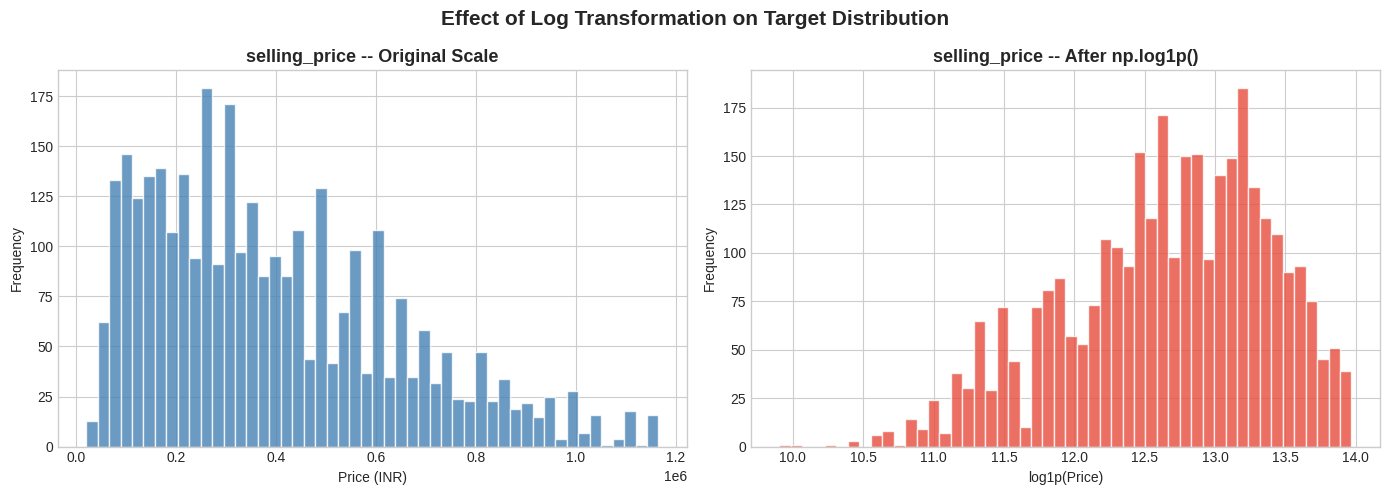

Observation: The log-transformed distribution is more symmetric (bell-shaped),
better satisfying the normality assumption of linear regression.


In [29]:
# Compare distributions: original vs log-transformed
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(y_multi_train, bins=50, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].set_title('selling_price -- Original Scale', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Price (INR)')
axes[0].set_ylabel('Frequency')

axes[1].hist(np.log1p(y_multi_train), bins=50, color='#e74c3c', edgecolor='white', alpha=0.8)
axes[1].set_title('selling_price -- After np.log1p()', fontsize=13, fontweight='bold')
axes[1].set_xlabel('log1p(Price)')
axes[1].set_ylabel('Frequency')

plt.suptitle('Effect of Log Transformation on Target Distribution',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()
print('Observation: The log-transformed distribution is more symmetric (bell-shaped),')
print('better satisfying the normality assumption of linear regression.')

3. **Cross-Validation**

Use KFold (k=5) to get a more reliable R² estimate for both models.

In [30]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Simple LR pipeline
pipe_simple = Pipeline([
    ('scaler', StandardScaler()),
    ('lr',     LinearRegression())
])
cv_simple = cross_val_score(
    pipe_simple, df[['km_driven']], df['selling_price'], cv=kf, scoring='r2'
)

# Multiple LR pipeline
numeric_cv = ['km_driven', 'car_age']
prep_cv = ColumnTransformer(
    transformers=[('num', StandardScaler(), numeric_cv)],
    remainder='passthrough'
)
pipe_multi_cv = Pipeline([
    ('prep', prep_cv),
    ('lr',   LinearRegression())
])
cv_multi = cross_val_score(
    pipe_multi_cv, X_multi, y_multi, cv=kf, scoring='r2'
)

print('=' * 60)
print('           5-FOLD CROSS-VALIDATION RESULTS')
print('=' * 60)
print(f'  Simple LR   R2 per fold : {[round(s,4) for s in cv_simple]}')
print(f'  Simple LR   Mean R2     : {cv_simple.mean():.4f}  (Std: {cv_simple.std():.4f})')
print()
print(f'  Multiple LR R2 per fold : {[round(s,4) for s in cv_multi]}')
print(f'  Multiple LR Mean R2     : {cv_multi.mean():.4f}  (Std: {cv_multi.std():.4f})')
print('=' * 60)

           5-FOLD CROSS-VALIDATION RESULTS
  Simple LR   R2 per fold : [np.float64(0.0465), np.float64(0.023), np.float64(0.0765), np.float64(0.0469), np.float64(0.0548)]
  Simple LR   Mean R2     : 0.0495  (Std: 0.0172)

  Multiple LR R2 per fold : [np.float64(0.537), np.float64(0.4899), np.float64(0.5465), np.float64(0.5165), np.float64(0.5422)]
  Multiple LR Mean R2     : 0.5264  (Std: 0.0210)


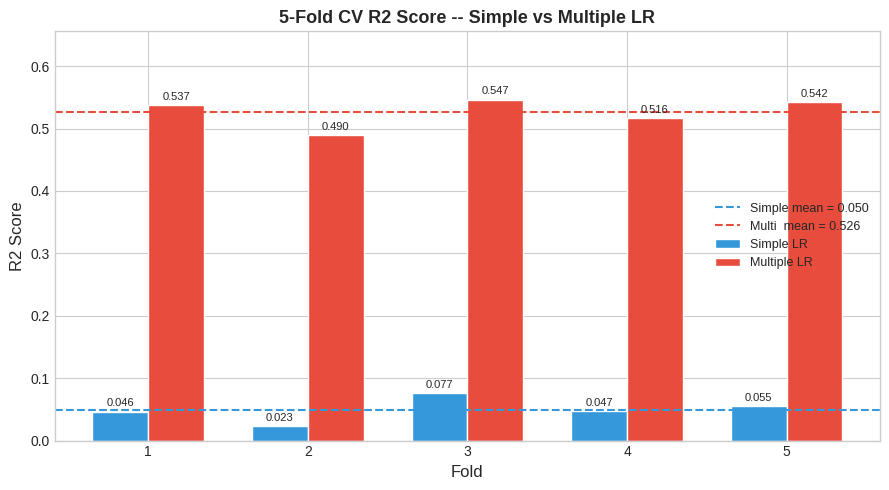

Conclusion: Cross-validation confirms Multiple LR (mean R2 = 0.5264)
consistently outperforms Simple LR (mean R2 = 0.0495) across all 5 folds.
This proves the performance difference is real, not a result of a lucky data split.


In [31]:
# Grouped bar chart: R2 per fold for both models
folds = np.arange(1, 6)
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(folds - width/2, cv_simple, width, label='Simple LR',
               color='#3498db', edgecolor='white')
bars2 = ax.bar(folds + width/2, cv_multi,  width, label='Multiple LR',
               color='#e74c3c', edgecolor='white')

for bar in list(bars1) + list(bars2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

ax.axhline(cv_simple.mean(), color='#3498db', linestyle='--', linewidth=1.5,
           label=f'Simple mean = {cv_simple.mean():.3f}')
ax.axhline(cv_multi.mean(),  color='#e74c3c', linestyle='--', linewidth=1.5,
           label=f'Multi  mean = {cv_multi.mean():.3f}')

ax.set_xlabel('Fold', fontsize=12)
ax.set_ylabel('R2 Score', fontsize=12)
ax.set_title('5-Fold CV R2 Score -- Simple vs Multiple LR', fontsize=13, fontweight='bold')
ax.set_xticks(folds)
ax.legend(fontsize=9)
ax.set_ylim(0, max(cv_multi.max(), cv_simple.max()) * 1.2)
plt.tight_layout()
plt.show()

print(f'Conclusion: Cross-validation confirms Multiple LR (mean R2 = {cv_multi.mean():.4f})')
print(f'consistently outperforms Simple LR (mean R2 = {cv_simple.mean():.4f}) across all 5 folds.')
print('This proves the performance difference is real, not a result of a lucky data split.')